Data Preparation and Preliminary Analysis and Scenario Analysis Report

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set()

df = pd.read_csv("C:/Users/cis101/Documents/mal_anime.csv")

comma_cols = ["Members", "Favorites", "Ranked"]

for col in comma_cols:
    df[col] = df[col].astype(str).str.replace(",","")
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.head()
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19931 entries, 0 to 19930
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   myanimelist_id   19931 non-null  int64  
 1   title            19931 non-null  object 
 2   description      19875 non-null  object 
 3   image            19544 non-null  object 
 4   Type             19534 non-null  object 
 5   Episodes         19549 non-null  object 
 6   Status           19549 non-null  object 
 7   Premiered        6343 non-null   object 
 8   Released_Season  6182 non-null   object 
 9   Released_Year    6182 non-null   float64
 10  Source           19166 non-null  object 
 11  Genres           18270 non-null  object 
 12  Themes           11217 non-null  object 
 13  Studios          19549 non-null  object 
 14  Producers        19549 non-null  object 
 15  Demographic      6522 non-null   object 
 16  Duration         19549 non-null  object 
 17  Rating      

,myanimelist_id,title,description,image,Type,Episodes,Status,Premiered,Released_Season,Released_Year,...,Demographic,Duration,Rating,Score,Ranked,Popularity,Members,Favorites,characters,source_url
count,19931.00000,19931,19875,19544,19534,19549,19549,6343,6182,6182.000000,...,6522,19549,19057,15239.000000,0.0,19549,1.954900e+04,19549.000000,13519,19931
unique,NaN,19930,17393,19511,7,326,3,251,4,NaN,...,5,331,6,NaN,NaN,17003,NaN,NaN,12835,19931
top,NaN,Shen Lan Qi Yu Wushuang Zhu: Tianmo Pian,No synopsis information has been added to this...,https://cdn.myanimelist.net/img/common/externa...,TV,1,Finished Airing,?,Spring,NaN,...,Kids,24 min. per ep.,PG-13 - Teens 13 or older,NaN,NaN,#18479,NaN,NaN,"[{""id"": 233179, ""name"": ""President"", ""url"": ""h...",https://myanimelist.net/anime/62894/Fengkuang_...
freq,NaN,2,2297,28,6343,5875,18668,161,1944,NaN,...,2825,2027,8548,NaN,NaN,4,NaN,NaN,20,1
mean,29360.01726,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2010.129893,...,NaN,NaN,NaN,6.539627,NaN,NaN,5.655706e+04,634.577472,NaN,NaN
std,20509.69310,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.249090,...,NaN,NaN,NaN,0.866174,NaN,NaN,2.014348e+05,5510.208551,NaN,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1961.000000,...,NaN,NaN,NaN,1.890000,NaN,NaN,1.800000e+01,0.000000,NaN,NaN
25%,7935.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2005.000000,...,NaN,NaN,NaN,5.940000,NaN,NaN,6.500000e+02,0.000000,NaN,NaN
50%,32559.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.000000,...,NaN,NaN,NaN,6.520000,NaN,NaN,3.690000e+03,5.000000,NaN,NaN
75%,48176.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020.000000,...,NaN,NaN,NaN,7.160000,NaN,NaN,2.347200e+04,51.000000,NaN,NaN


In [2]:
#Clean and convert features
df["Members"] = (
    df["Members"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

df["Favorites"] = (
    df["Favorites"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

df["Episodes"] = pd.to_numeric(df["Episodes"], errors="coerce")

df["Ranked"] = (
    df["Ranked"]
    .astype(str)
    .str.replace("#", "", regex=False)
    .astype(float)
)
df["Ranked"] = pd.to_numeric(df["Ranked"], errors="coerce")

num_cols = ["Score", "Members", "Favorites", "Episodes", 
            "Ranked", "Released_Year"]
df[num_cols].describe()

,Score,Members,Favorites,Episodes,Ranked,Released_Year
count,15239.000000,1.954900e+04,19549.000000,18872.000000,0.0,6182.000000
mean,6.539627,5.655706e+04,634.577472,13.637823,NaN,2010.129893
std,0.866174,2.014348e+05,5510.208551,43.691253,NaN,13.249090
min,1.890000,1.800000e+01,0.000000,1.000000,NaN,1961.000000
25%,5.940000,6.500000e+02,0.000000,1.000000,NaN,2005.000000
50%,6.520000,3.690000e+03,5.000000,3.000000,NaN,2014.000000
75%,7.160000,2.347200e+04,51.000000,13.000000,NaN,2020.000000
max,9.290000,4.248837e+06,244671.000000,1818.000000,NaN,2027.000000


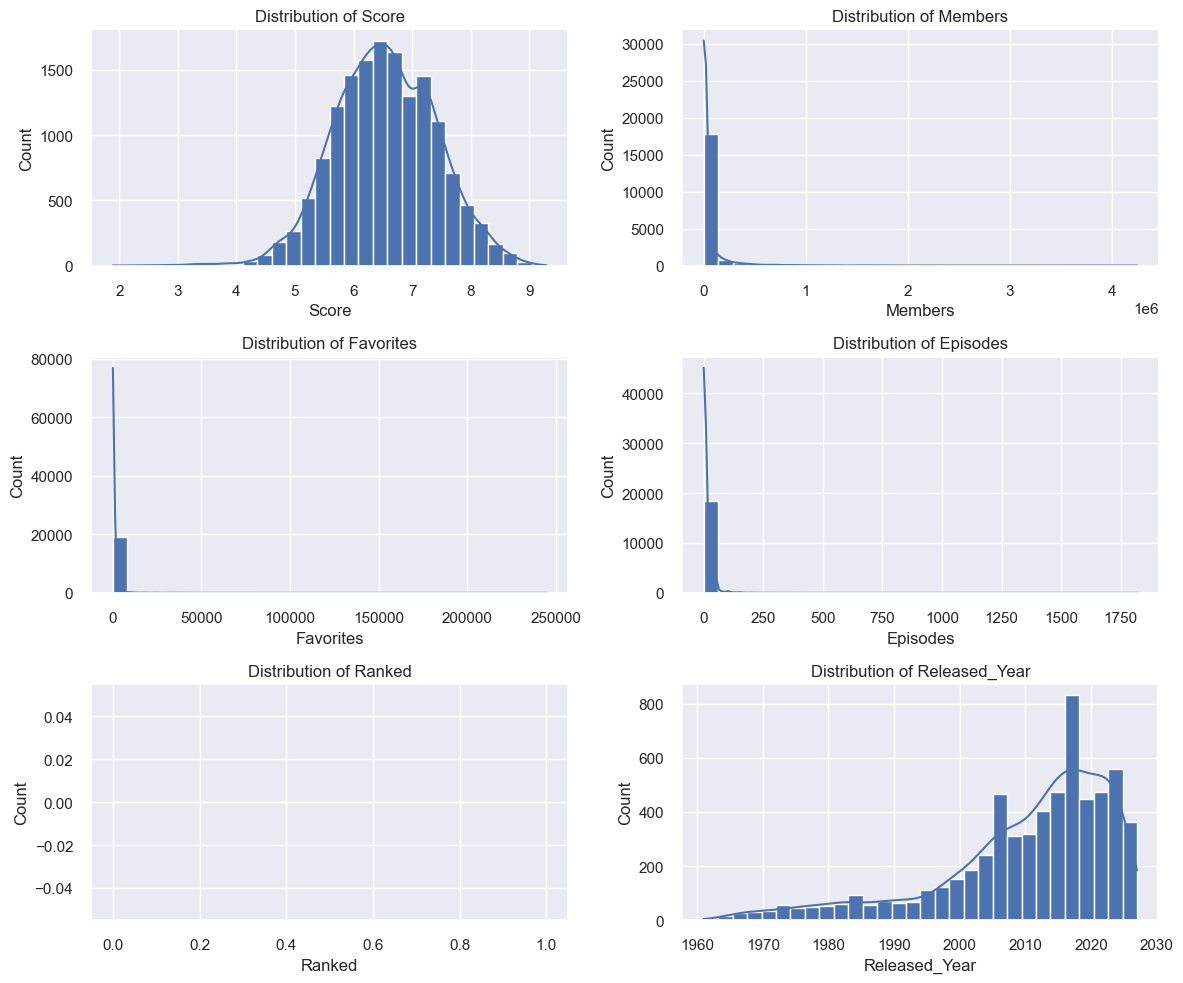

In [3]:
#Histogram for the numerical features
df[num_cols].hist(bins=30, figsize=(12, 10))

for i, col in enumerate(num_cols):
    plt.subplot(3, 2, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [4]:
#Boxplots for the outliers
#plt.figure(figsize=(12, 8))

#for i, col in enumerate(num_cols):
   # plt.subplot(3, 2, i+1)
    #sns.boxplot(x=df[col])
    #plt.title(f"Boxplot of {col}")

#plt.tight_layout()
#plt.show()

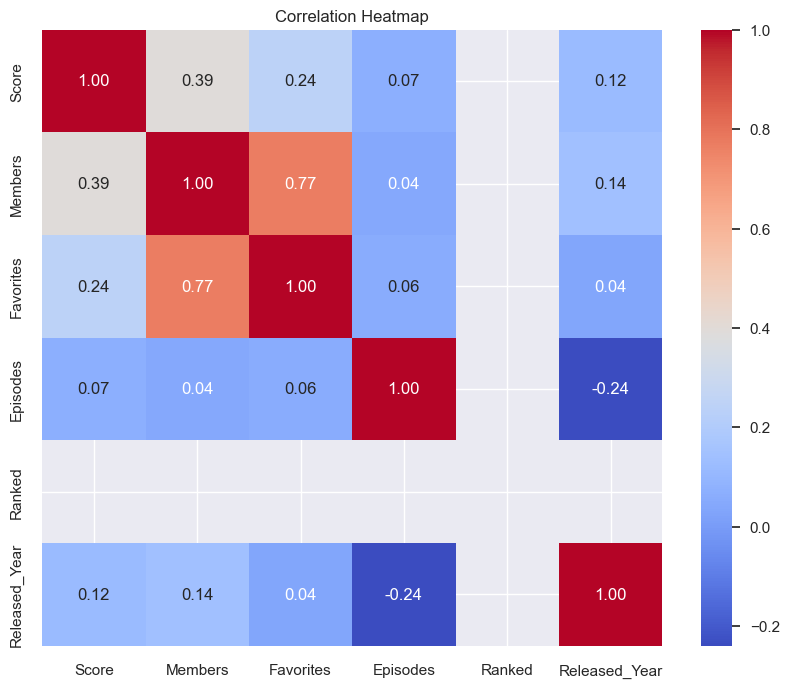

,Score,Members,Favorites,Episodes,Ranked,Released_Year
Score,1.000000,0.393411,0.241965,0.066780,NaN,0.116033
Members,0.393411,1.000000,0.768628,0.041387,NaN,0.141330
Favorites,0.241965,0.768628,1.000000,0.059925,NaN,0.035607
Episodes,0.066780,0.041387,0.059925,1.000000,NaN,-0.239473
Ranked,NaN,NaN,NaN,NaN,NaN,NaN
Released_Year,0.116033,0.141330,0.035607,-0.239473,NaN,1.000000


In [5]:
#Correlation Matrix
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

corr

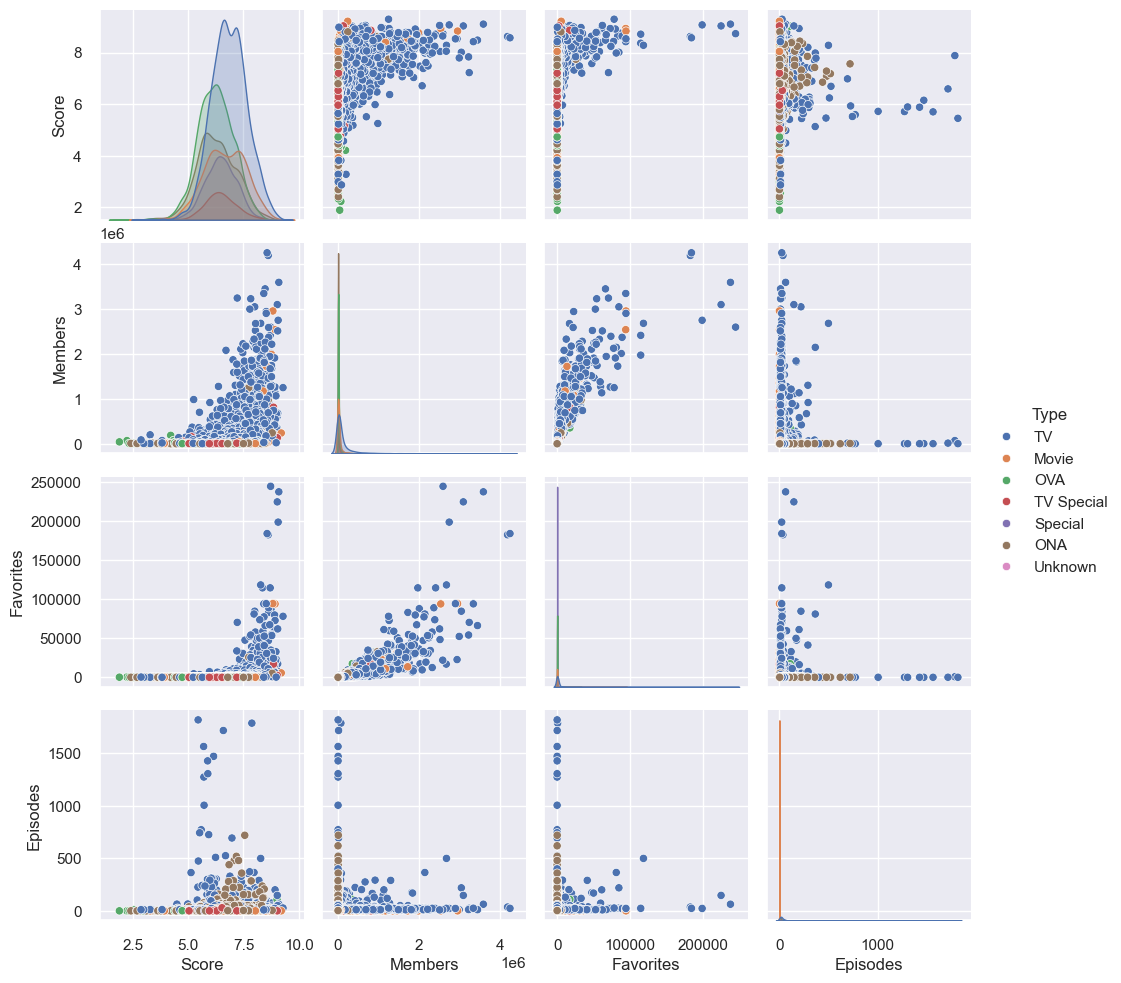

In [6]:
#Pair Plot
pair_cols=["Score", "Members", "Favorites",
           "Episodes", "Type"]

sns.pairplot(df[pair_cols], hue="Type", diag_kind="kde")
plt.show()

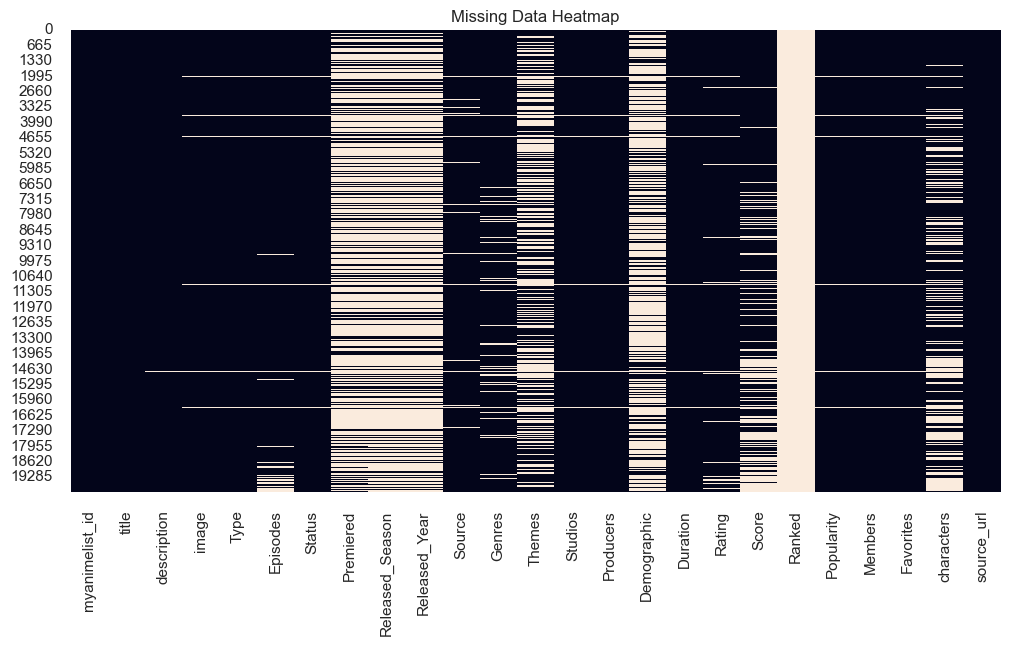

In [7]:
#Missing data heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isna(), cbar=False)
plt.title("Missing Data Heatmap")
plt.show()

In [8]:
#Data preprocessing 
from sklearn.preprocessing import StandardScaler

#redifinning num and cat columns
num_cols = [ "Score", "Members", "Favorites", "Episodes", "Ranked", "Released_Year"]
cat_cols = [ "Type", "Rating", "Source"]

#Handle missing values
df_clean = df.copy()

#Impute with meadian (numeric columns)
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

#impute with mode (categorical columns)
cat_cols = ["Type", "Rating", "Source"]
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

#one-hot encode for cat features
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

#scale num features
scaler = StandardScaler()
df_encoded[num_cols] = df_encoded[num_cols].fillna(df_encoded[num_cols].median())

C:\Users\cis101\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [9]:
#Final feature set

final_num_cols = [ "Score", "Members", "Favorites", "Episodes",
                  "Ranked", "Released_Year"]
cat_cols = ["Type", "Rating", "Source"]

encoded_cols = [ col for col in df_encoded.columns
                if any(col.startswith(c + "_") for c in cat_cols)]

final_features = final_num_cols[1:] + encoded_cols

In [10]:
df_encoded = df_encoded.drop(columns=["Ranked"])
final_num_cols.remove("Ranked")
num_cols.remove("Ranked")

encoded_cols = [col for col in df_encoded.columns if any(col.startswith(c+ "-") for c in cat_cols)]
final_features = final_num_cols[1:] + encoded_cols

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X = df_encoded[final_features]
Y = df_encoded["Score"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

baseline_model = LinearRegression()
baseline_model.fit(X_train, Y_train)

Y_pred = baseline_model.predict(X_test)

# Metrics
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

print("Baseline Model Performance:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)


Baseline Model Performance:
MAE: 0.4921366011974838
MSE: 0.4767117499477897
RMSE: 0.690443154754821
R2: 0.15415244844436615


In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

nn_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

nn_model.summary()

C:\Users\cis101\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = nn_model.fit(
    X_train, Y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 59021288.0000 - mae: 1301.1261 - val_loss: 18785.1738 - val_mae: 65.4053
Epoch 2/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1532379.0000 - mae: 203.5479 - val_loss: 50344.1797 - val_mae: 88.9387
Epoch 3/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 10128.8428 - mae: 30.8723 - val_loss: 1979.8064 - val_mae: 11.0494
Epoch 4/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1361.3215 - mae: 12.0168 - val_loss: 254.7476 - val_mae: 6.4362
Epoch 5/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 125209.3281 - mae: 17.8919 - val_loss: 12357461.0000 - val_mae: 912.0046
Epoch 6/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 5052418.5000 - mae: 467.0343 - val_loss: 83459.5469 - val_mae: 50.1115
Epoch 7/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 485526.8438 - mae: 84.0312 - val_loss: 448728.0312 - val_mae: 199.9584
Epoch 8/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 234253.5156 - mae: 92.4952 - v

In [14]:
nn_pred = nn_model.predict(X_test)

nn_mae = mean_absolute_error(Y_test, nn_pred)
nn_mse = mean_squared_error(Y_test, nn_pred)
nn_rmse = np.sqrt(nn_mse)
nn_r2 = r2_score(Y_test, nn_pred)

print("Neural Network Performance:")
print("MAE:", nn_mae)
print("MSE:", nn_mse)
print("RMSE:", nn_rmse)
print("R2:", nn_r2)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step   
Neural Network Performance:
MAE: 0.9019666764070613
MSE: 29.55928219948795
RMSE: 5.436844875429862
R2: -51.448143929570115


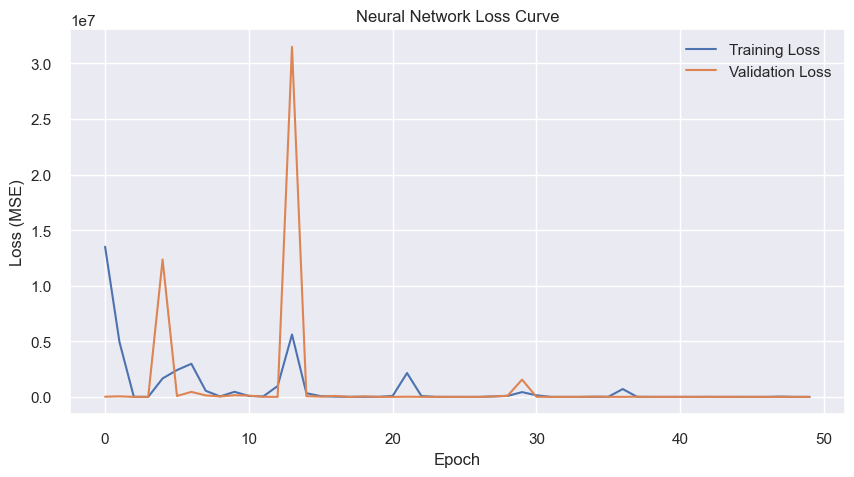

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Neural Network Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

In [16]:
print("Baseline RMSE:", rmse)
print("Neural Network RMSE:", nn_rmse)

print("Baseline R2:", r2)
print("Neural Network R2:", nn_r2)



Baseline RMSE: 0.690443154754821
Neural Network RMSE: 5.436844875429862
Baseline R2: 0.15415244844436615
Neural Network R2: -51.448143929570115


Scenario Analysis

Scenario 1 - High Popularity Surge
Assumption: A major streaming platform promotes certain anime, causing a spike in member counts.
Changes: members increased by 50% and favorites increased by 30%
This matters because it shows how popularity boosts predicted score.

Scenario 2 - Low episode Short Series Trend
Assumption: Short anime (12 episodes or less) become more common
Changes: episodes are capped at 12 and members reduced by 20% as shorter shows have smaller audiences
This matters because it tests how shorter formats are affect predicted score.

Scenario 3 - Classic Anime Revival
Assumption: Older anime get renewed attention
Changes: released_year is set between 1990 and 2005, members increased by 40% and favorites increased by 25%
This matters because it tests how older shows perform under renewed interest.

In [17]:
def preprocess_scenario(df_scenario):
    # keep only the columns used in training
    df_scenario = df_scenario[["Score", "Members", "Favorites", "Episodes", "Released_Year", "Type", "Rating", "Source"]]
    # impute numeric columns
    for col in num_cols:
        df_scenario[col] = df_scenario[col].fillna(df_scenario[col].median())

    # impute cat columns
    for col in cat_cols:
        df_scenario[col] = df.scenario[col].fillna(df_scenario[col].mode()[0])

    # one hot encode
    df_scenario_encoded = pd.get_dummies(df_scenario, columns=cat_cols, drop_first=True)

    # add missing encoded columns to match the previous training
    for col in encoded_cols:
        if col not in df_scenario_encoded.columns:
            df_scenario_encoded[col] = 0
    
    # ensure correct column order
    df_scenario_encoded = df_scenario_encoded[final_features]

    # scale numeric columns using standardscaler
    df_scenario_encoded[final_num_cols[1:]] = scaler.transform(df_scenario_encoded[final_num_cols[1:]])

    return df_scenario_encoded

In [18]:
import pandas as pd

df = pd.read_excel("Cleaned_MALanime_dashboard.xlsx")
df = df.drop(columns=["Ranked"])

# Scenario 1: High popularity trends
scenario1 = df.copy()
scenario1["Members"] = scenario1["Members"] * 1.5
scenario1["Favorites"]= scenario1["Favorites"] * 1.3
scenario1_processed = preprocess_scenario(scenario1)
pred1 = nn_model.predict(scenario1_processed)

# Scenario 2: Short serries trend
scenario2 = df.copy()
scenario2["Episodes"] = scenario2["Episodes"].clip(upper=12)
scenario2["Members"] = scenario2["Members"] * 0.8
scenario2_processed = preprocess_scenario(scenario2)
pred2 = nn_model.predict(scenario2_processed)

# Scenario 3: Classic anime revival
scenario3 = df.copy()
scenario3["Released_Year"] = scenario3["Released_Year"].clip(lower=1990, upper=2005)
scenario3["Members"] = scenario3["Members"] * 1.4
scenario3["Favorites"] = scenario3["Favorites"] * 1.25
scenario3_processed = preprocess_scenario(scenario3)
pred3 = nn_model.predict(scenario3_processed)

# baseline
baseline_processed = preprocess_scenario(df)
baseline_pred = nn_model.predict(baseline_processed)

#export
results = pd.DataFrame({
    "Baseline": nn_model.predict(df),
    "Scenario1": pred1,
    "Scenario2": pred2,
    "Scenario3": pred3
})

results.to_excel("scenario_results.xlsx", index=False)


SyntaxError: invalid syntax (4197756928.py, line 8)

In [ ]:
df.columns